In [49]:
import sys
import os
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import json
import numpy as np
import time
import re
from ftfy import fix_text
import pickle




In [50]:
df_articles = pd.read_pickle("../../data/processed/duplicates_analysis.pkl")

In [51]:
df_articles.head()

,title,publisher,date,section,length,body,correction_appended,load_date_at_end,source_file,exact_duplicate,title_stand,near_duplicate_matching_title,duplicate_of_index_90,near_duplicates_new,near_duplicates_new_index
0,Fleece of the Century; On Boxing,The New York Times,2017-08-27,SPORTS,1958 words,LAS VEGAS — The world finally had the two of t...,False,False,NYT/22.DOCX,False,fleece of the century on boxing,False,NaN,False,NaN
1,MOUNT WASHINGTON CORRIDOR TARGETED FOR DESIGN ...,Pittsburgh Post-Gazette,2016-05-02,LOCAL; WALKABOUT; Pg. A-9,700 words,"Practicality has its place, but it's unlikely ...",False,False,Other publishers/Files (500) (12).DOCX,False,mount washington corridor targeted for design ...,False,NaN,False,NaN
2,HOW ORMSBY PLAYGROUND SAVED US;\nRICHARD PETER...,Pittsburgh Post-Gazette (Pennsylvania),2005-07-31,"EDITORIAL,",803 words,I spent a good part of my teen-age years in th...,False,False,Other publishers/Files (500) (13).DOCX,True,how ormsby playground saved usrichard peterson...,True,498.0,False,NaN
3,"As Republicans rap Fetterman's workload, he ca...",The Philadelphia Inquirer,2022-10-07,NEWS; Pg. A4,587 words,When John Fetterman started running for U.S. S...,False,False,Other publishers/Files (500) (3).DOCX,False,as republicans rap fettermans workload he call...,False,NaN,False,NaN
4,"Ruined Towns, Long Lines and Angry Voices in t...",The New York Times,2017-10-04,Section A; Column 0; National Desk; Pg. 11,964 words,"FREDERIKSTED, V.I. -- On Tuesday morning, as P...",False,False,NYT/23.DOCX,False,ruined towns long lines and angry voices in th...,False,NaN,False,NaN


In [52]:
df_articles['near_duplicates_new'].sum()

np.int64(3237)

In [92]:
df_articles['near_duplicate_matching_title'].sum()

np.int64(1867)

In [96]:
df_articles.loc[(df_articles['near_duplicates_new']) | (df_articles['near_duplicate_matching_title'])].shape[0]

3416

In [67]:
new_duplicates_df = df_articles.loc[df_articles['near_duplicates_new'].apply(lambda x: str(x) == "True")]
new_duplicates_df.head()

,title,publisher,date,section,length,body,correction_appended,load_date_at_end,source_file,exact_duplicate,title_stand,near_duplicate_matching_title,duplicate_of_index_90,near_duplicates_new,near_duplicates_new_index
162,Hochul Unveiled a Sweeping Vision for New York...,The New York Times,2022-01-13,NYREGION,1504 words,After laying out her priorities in the State o...,False,False,NYT/10.DOCX,False,hochul unveiled a sweeping vision for new york...,False,NaN,True,74.0
176,Gerrymandering and the Rising Risk of a Monopo...,The New York Times,2019-06-28,UPSHOT,1483 words,"At some point or another over the last decade,...",False,False,NYT/22.DOCX,False,gerrymandering and the rising risk of a monopo...,False,NaN,True,88.0
184,'Jimmy's Hall': Socialist crusader vs. powers ...,The Philadelphia Inquirer,2015-07-17,FEATURES WEEKEND; P-com Ent. Movies; Pg. 00,380 words,"Jimmy's Hall, Ken Loach's loving dramatization...",False,False,Other publishers/Files (500) (9).DOCX,True,jimmys hall socialist crusader vs powers that be,True,0.0,True,8.0
326,Democratic Socialism Is Dem Doom,The New York Times,2018-07-07,Section A; Column 0; Editorial Desk; Pg. 19; O...,892 words,A political novice who calls herself a ''democ...,False,False,NYT/16.DOCX,False,democratic socialism is dem doom,False,NaN,True,150.0
356,Are you middle class? The answer is trickier t...,The Philadelphia Inquirer,2017-10-12,WEB; P-com News; Pg. WEB,859 words,Wooden storm windows on your house say you are...,False,False,Other publishers/Files (500) (6).DOCX,True,are you middle class the answer is trickier th...,True,3.0,True,271.0


In [72]:
ex_number = 0
index_duplicate = new_duplicates_df.index[ex_number]
index_original = new_duplicates_df.near_duplicates_new_index.iloc[ex_number]

duplicate_article = df_articles.iloc[index_duplicate ]
original_article = df_articles.iloc[int(index_original) ]

In [85]:
print(f"Title 1: {duplicate_article['title']}\n\nTitle 2: {original_article['title']}")

Title 1: Hochul Unveiled a Sweeping Vision for New York. Now Comes the Hard Part.

Title 2: Hochul Unveiled Vision for New York. Now Comes the Hard Part.


In [89]:
print("Body 1:\n\n", duplicate_article['body'][:2000])

Body 1:

 After laying out her priorities in the State of the State address, Gov. Kathy Hochul must now work with the Legislature to back her with funding and new laws.
ALBANY, N.Y. — When Gov. Kathy Hochul unveiled her policy agenda for New York last week, she appeased unions with her commitment to boost wages, appealed to business leaders with business-friendly rhetoric and threw in crowd-pleasers, such as proposals to fix potholes and allow bars and restaurants to sell to-go drinks.
But her most explicit overtures were directed at one audience: state lawmakers.
Promising a "new era" of collaboration, Ms. Hochul pledged to "share success" and "find common ground" with legislators, declaring that "the days of governors disregarding the rightful role of this Legislature are over."
Over the coming months, Ms. Hochul, a moderate Democrat, will need to court and cajole state lawmakers to turn her expansive policy aspirations into reality when she negotiates her first state budget with Dem

In [91]:
print("Body 2:\n\n", original_article['body'][:2000])

Body 2:

 After laying out her priorities in the State of the State address, Gov. Kathy Hochul must now work with the Legislature to back her with funding and new laws.
ALBANY, N.Y. -- When Gov. Kathy Hochul unveiled her policy agenda for New York last week, she appeased unions with her commitment to boost wages, appealed to business leaders with business-friendly rhetoric and threw in crowd-pleasers, such as proposals to fix potholes and allow bars and restaurants to sell to-go drinks. 
  But her most explicit overtures were directed at one audience: state lawmakers.
  Promising a ''new era'' of collaboration, Ms. Hochul pledged to ''share success'' and ''find common ground'' with legislators, declaring that ''the days of governors disregarding the rightful role of this Legislature are over.''
  Over the coming months, Ms. Hochul, a moderate Democrat, will need to court and cajole state lawmakers to turn her expansive policy aspirations into reality when she negotiates her first state

Old duplicate but not new duplicate:

In [105]:
df_old_but_not_new = df_articles.loc[(~df_articles['near_duplicates_new']) & (df_articles['near_duplicate_matching_title'])]
print("Number of cases resulting in duplicate match in old method but not new method: ", df_old_but_not_new.shape[0])
ex_number = 0
index_duplicate = df_old_but_not_new.index[ex_number]
index_original = df_old_but_not_new.duplicate_of_index_90.iloc[ex_number]

duplicate_article = df_articles.iloc[index_duplicate ]
original_article = df_articles.iloc[int(index_original) ]

Number of cases resulting in duplicate match in old method but not new method:  179


In [106]:
print(f"Title 1: {duplicate_article['title']}\n\nTitle 2: {original_article['title']}")

Title 1: HOW ORMSBY PLAYGROUND SAVED US;
RICHARD PETERSON RECALLS THE VALUE OF A RECREATION CENTER TO CITY KIDS WHO COULD'VE BEEN UP TO NO GOOD

Title 2: States Seize Chance to Stop College Student Brain Drain


In [119]:
print("Body 1:\n\n", duplicate_article['body'][:2000])

Body 1:

 I spent a good part of my teen-age years in the 1950s playing ball and hanging out at Ormsby recreation center and playground on the South Side. Closed by the city after massive layoffs in August 2003 and only recently re-opened, Ormsby first offered its facilities to working-class South Side families during the Great Depression.
 Built in 1939, the same year I was born, as a Works Project Administration program, Ormsby was a miracle of planning and construction.  When it was finished, it had a ball field, basketball and paddle ball courts, an outdoor swimming pool, and an indoor recreation center, all within an area one city block wide and less than two city blocks long, and bounded by streetcar tracks, row houses, a sand and gravel company, a branch of the Carnegie Library, and the entrance to the doomed Brady Street Bridge.
These days communities like those surrounding Westinghouse Park -- Homewood and North Point Breeze in the East End -- are capable of squabbling over wh

In [120]:
print("Body 2:\n\n", original_article['body'][:2000])

Body 2:

 MORGANTOWN, W.Va. -- On a crisp day in November, three young men gathered at the tiny municipal airport in Morgantown, just minutes from West Virginia University's campus. One paced nervously, having never flown before. Another was dressed as the university's mascot, wearing buckskin and toting a rifle. The third was reading a book, Ralph Ellison's ''Invisible Man.''
The three men, all W.V.U. students, were boarding a private plane for a recruiting trip to McDowell County, the remote heart of Appalachia, with Gordon Gee, the university's president. Their job was to persuade some of the state's most promising high school students to stay home for college, like they did, and not be tempted by the glamour and mystique of elite schools in faraway states. 
  ''I've joked about the fact that I want to build a wall around West Virginia and keep all the kids here,'' Dr. Gee said, chuckling. ''A state can't flourish that can't keep its young people there.''
  State-funded universities

# Duplicates

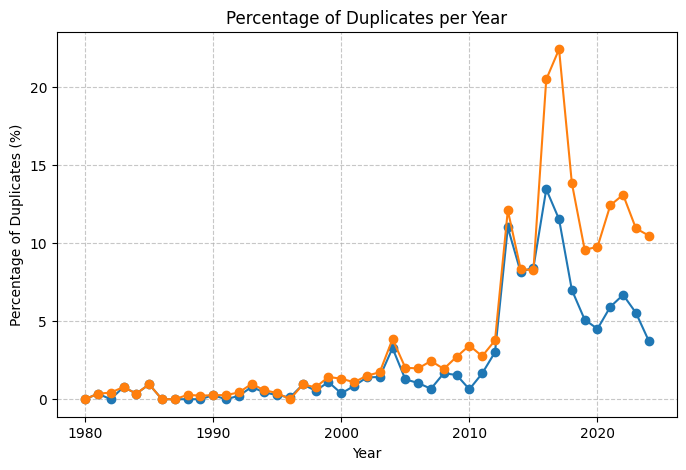

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure date column is datetime
df_articles['date'] = pd.to_datetime(df_articles['date'])

# Extract year
df_articles['year'] = df_articles['date'].dt.year

# Group by year and calculate percentage of duplicates
dup_stats_old_method = df_articles.groupby('year')['near_duplicate_matching_title'].mean() * 100

# Group by year and calculate percentage of duplicates
dup_stats_new_method = df_articles.groupby('year')['near_duplicates_new'].mean() * 100


# Plot
plt.figure(figsize=(8,5))
plt.plot(dup_stats_old_method.index, dup_stats_old_method.values, marker='o')
plt.plot(dup_stats_new_method.index, dup_stats_new_method.values, marker='o')
plt.title("Percentage of Duplicates per Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Duplicates (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
